# FAPE, Lending Club Stage 2: ThresholdOptimizer
## Financial Services Domain, Income-Based Fairness Intervention

**Dataset:** Lending Club 2007-2018, 100,000 stratified sample from 1,348,099 records  
**Sensitive:** annual_inc_band (income quartile proxy), home_ownership (MORTGAGE vs RENT)  
**Target:** loan default (binary), 20.1% default rate  

**Key findings:**
- Income DP gap small (0.018-0.024), smallest fairness gap in FAPE financial domain
- DIR>1: model amplifies income disparity beyond actual rates (actual 1.4x, predicted 2.8x)
- Home ownership gap larger: MORTGAGE vs RENT DP=0.138-0.178, bigger fairness concern
- ThresholdOptimizer minimal improvement on income band, baseline already near-fair
- No direct race/gender, proxy-based ECOA audit
- ThresholdOptimizer non-deterministic in fairlearn 0.13.0, results vary slightly between runs

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
from stage2_lendingclub_threshold import run_stage2

os.makedirs('../figures/stage2', exist_ok=True)
print('Imports complete')

Imports complete


In [2]:
import os, sys
repo_root = os.path.abspath('..')
sys.path.insert(0, os.path.join(repo_root, 'src'))
from lending_club_loader import load_lending_club
from stage2_lendingclub_threshold import run_stage2
import importlib, stage2_lendingclub_threshold as m
# Patch data path to absolute
m.SAMPLE_SIZE = 100000
orig_dir = os.getcwd()
os.chdir(repo_root)
baseline, dp_results, eo_results, inc_test, home_test = run_stage2()
os.chdir(orig_dir)
print('Stage 2 complete')

FAPE Phase 4, Lending Club Stage 2: ThresholdOptimizer
Loading Lending Club data from data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv...


  Raw records: 2,260,701
  After binary outcome filter: 1,348,099


  Sampled to: 100,000 records
   lending_club: 100,000 rows | 23 features | default rate: 0.201

  n=100,000 stratified | default_rate=20.1%
  Primary sensitive: annual_inc_band (0=Q1 lowest to 3=Q4 highest)
  Secondary: home_ownership (0=MORTGAGE vs 1=RENT)
  Note: No direct race/gender, ECOA proxy-based audit
  Note: ThresholdOptimizer non-deterministic in fairlearn 0.13.0

--- Baseline Results (Stage 1 reference) ---


  LogisticRegression        AUC=0.706 DP_diff=0.018 EO_diff=0.038


  GradientBoosting          AUC=0.712 DP_diff=0.024 EO_diff=0.053

--- ThresholdOptimizer, Demographic Parity Constraint ---


...

  LogisticRegression        DP_diff=0.024 EO_diff=0.080 Acc=0.570 EO_improve=-0.042


  GradientBoosting          DP_diff=0.024 EO_diff=0.054 Acc=0.663 EO_improve=-0.001

--- Fairness Improvement Summary, Income Band (DP) ---
  LogisticRegression        DP before=0.018 after=0.019 improve=-0.001
  GradientBoosting          DP before=0.024 after=0.020 improve=+0.004

--- Fairness Improvement Summary, Income Band (EO) ---
  LogisticRegression        EO before=0.038 after=0.080 improve=-0.042
  GradientBoosting          EO before=0.053 after=0.054 improve=-0.001

--- Home Ownership Fairness, MORTGAGE vs RENT ---
  LogisticRegression        Home DP_diff=0.177 (MORTGAGE vs RENT)
  GradientBoosting          Home DP_diff=0.139 (MORTGAGE vs RENT)

--- Income Band Prediction Rates, GB Before vs After DP ---
  Q1-Low     before=0.028 after=0.397 change=+0.369
  Q2         before=0.034 after=0.412 change=+0.378
  Q3         before=0.016 after=0.397 change=+0.381
  Q4-High    before=0.010 after=0.416 change=+0.406

--- DIR, Income Band Before vs After DP ---
  LogisticRegression   

Loading Lending Club data from data/raw/lending_club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv...


  Raw records: 2,260,701
  After binary outcome filter: 1,348,099


  Sampled to: 100,000 records
   lending_club: 100,000 rows | 23 features | default rate: 0.201

--- Lending Club Stage 2 complete ---
  Income-based fairness intervention applied
  No direct race/gender, proxy-based ECOA audit
  Cross-domain: financial services income gap addressed
Stage 2 complete


## 1. Accuracy-Fairness Tradeoff

Income band DP gap small. ThresholdOptimizer improvement minimal, baseline already near-fair on income.

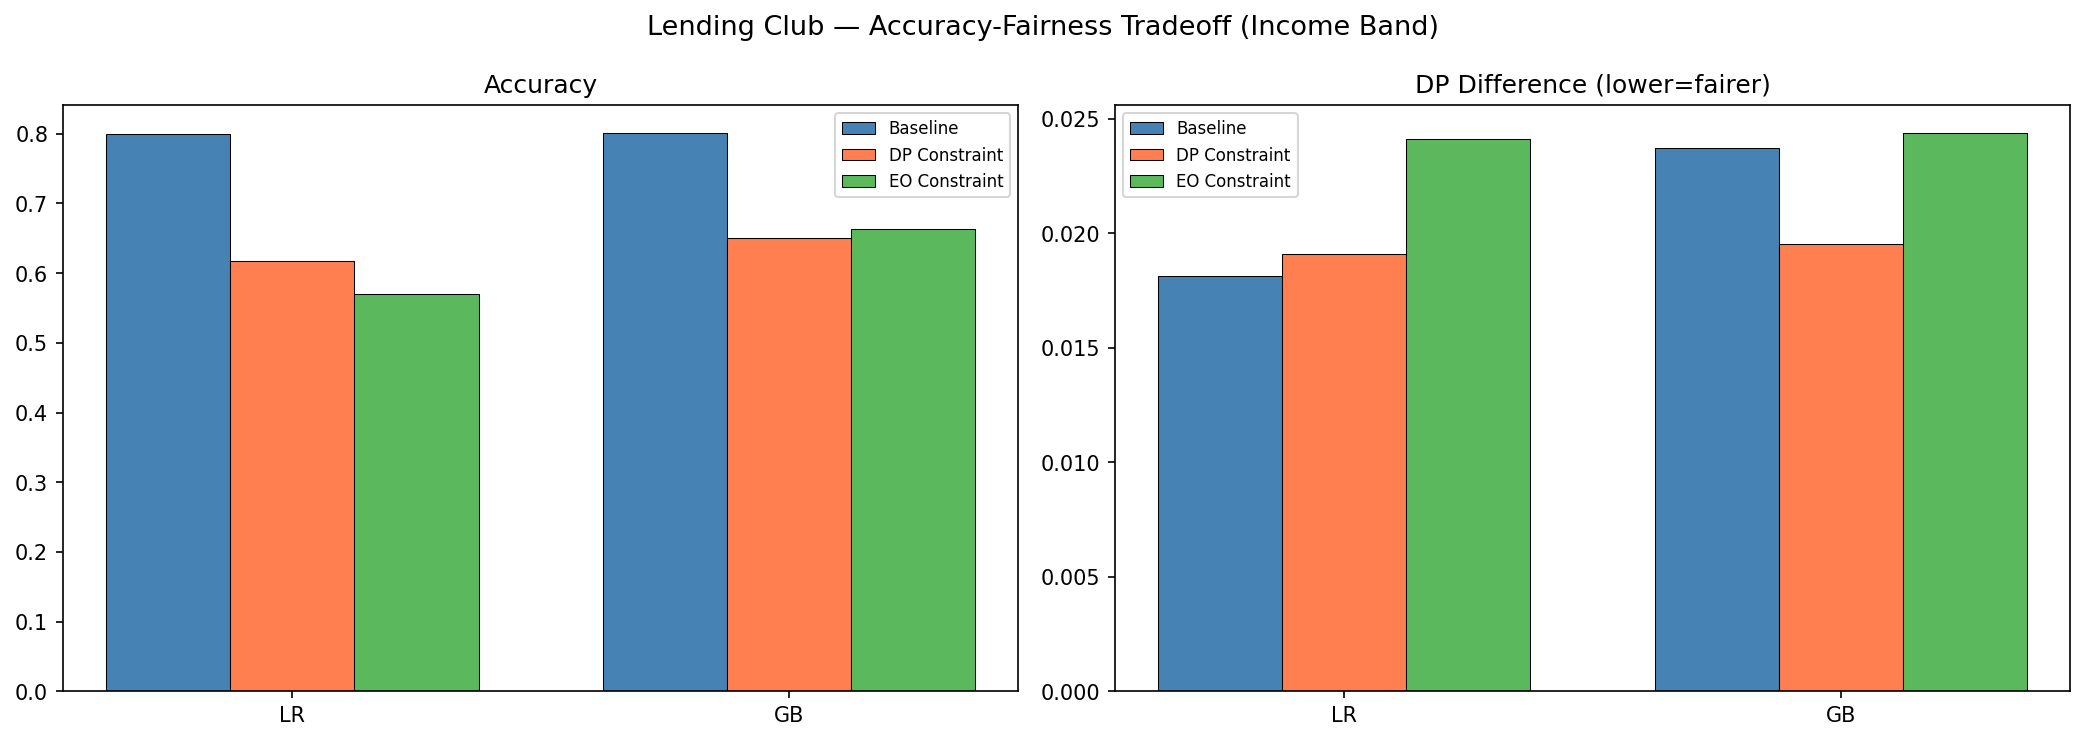

In [3]:
Image('../figures/stage2/lendingclub_accuracy_fairness_tradeoff.png')

## 2. Fairness Improvement, Income Band

Minimal improvement, income DP gap (0.018-0.024) is the smallest in FAPE. Contrast with Law School (0.329).

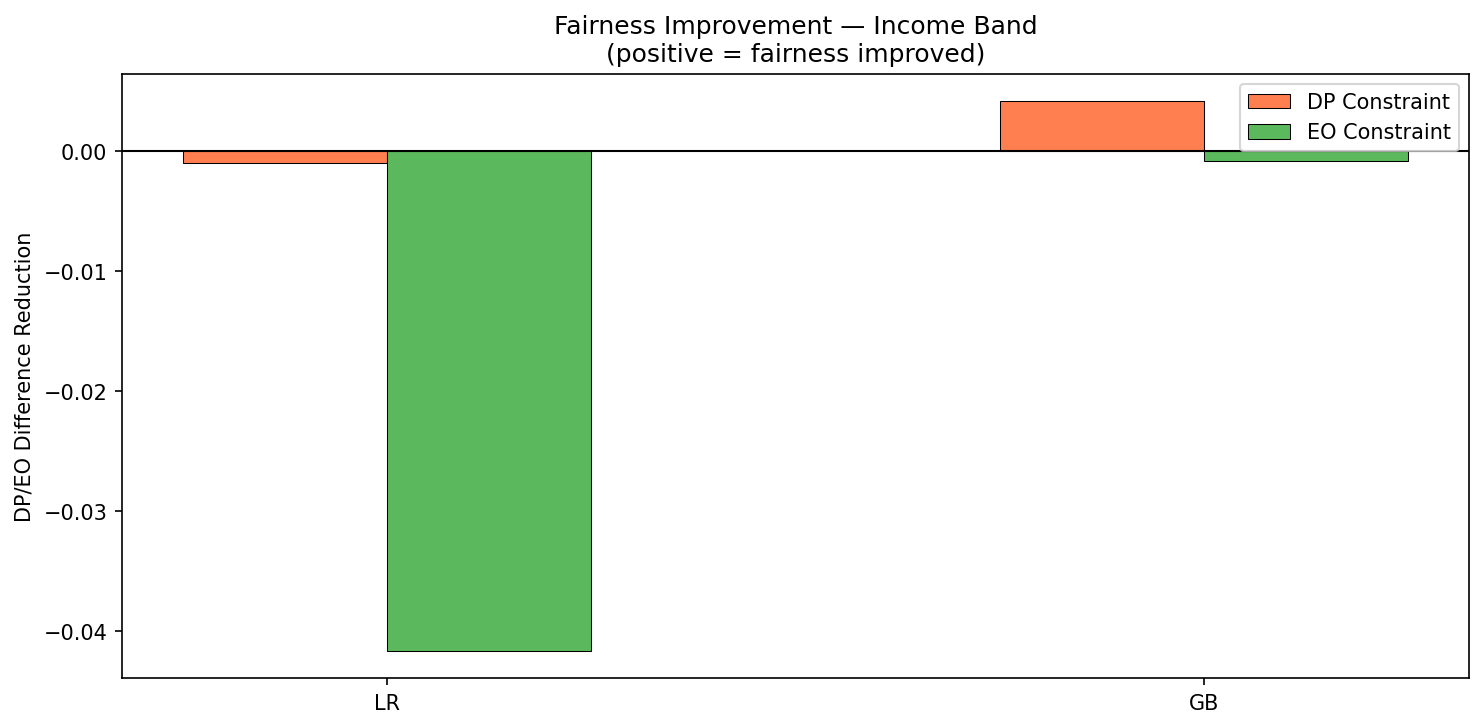

In [4]:
Image('../figures/stage2/lendingclub_fairness_improvement.png')

## 3. Cost-Gain Scatter

Accuracy cost with minimal fairness gain, income band is not the primary fairness concern here.

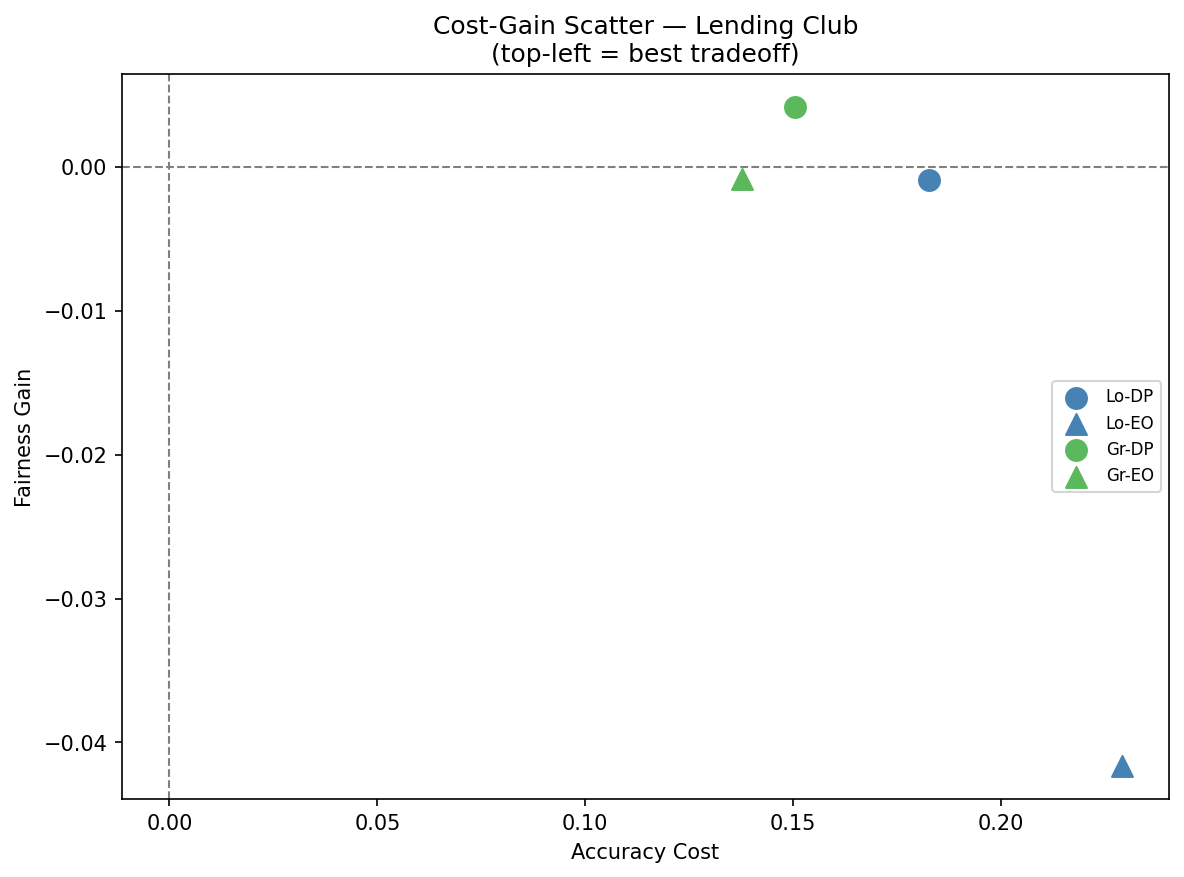

In [5]:
Image('../figures/stage2/lendingclub_cost_gain_scatter.png')

## 4. Home Ownership Fairness, MORTGAGE vs RENT

DP=0.138-0.178, 7-9x larger than income band gap. Renters face systematically higher default prediction rates.

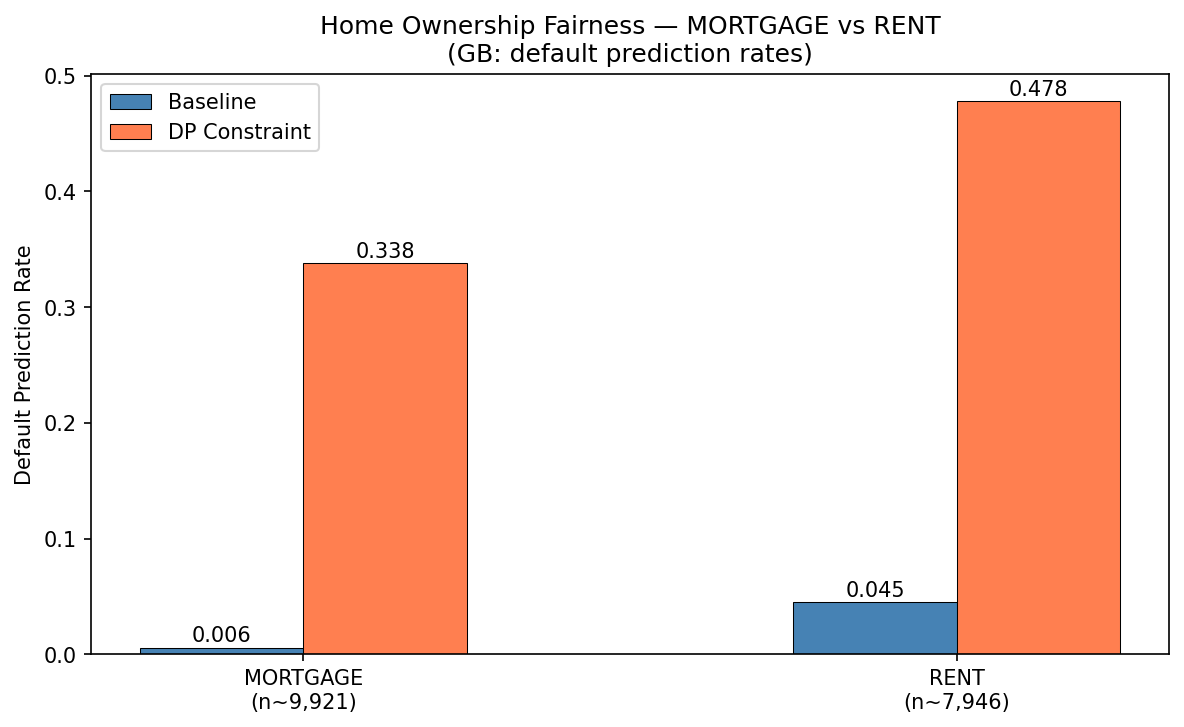

In [6]:
Image('../figures/stage2/lendingclub_home_ownership_fairness.png')

## 5. Income Band Prediction Rates

GB baseline predicts near-zero default for all bands, model severely underpredicts default. DP constraint corrects this.

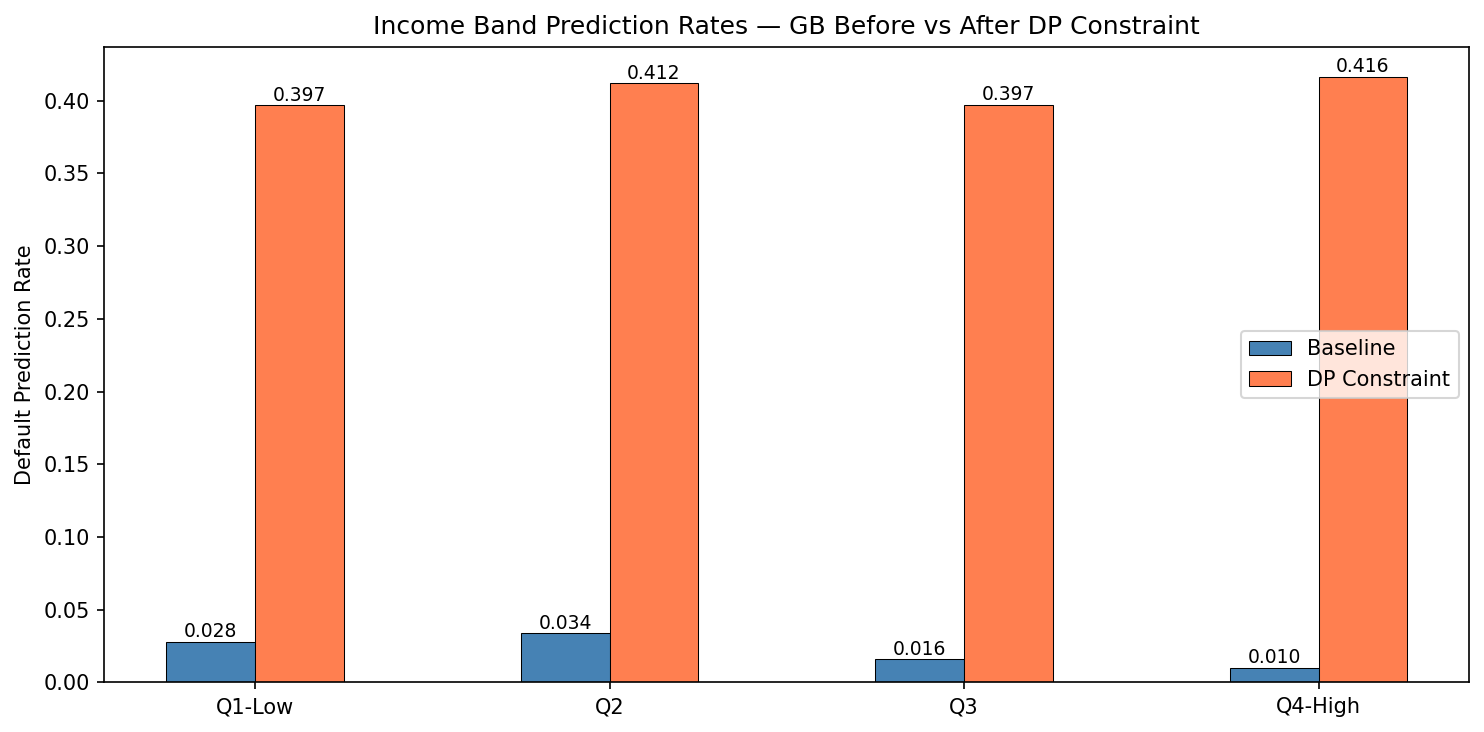

In [7]:
Image('../figures/stage2/lendingclub_income_band_rates.png')

## 6. Disparate Impact Ratio, Income Band

DIR>1 baseline: model amplifies income disparity (actual 1.4x, predicted 2.8x). DP constraint brings DIR toward 1.0.

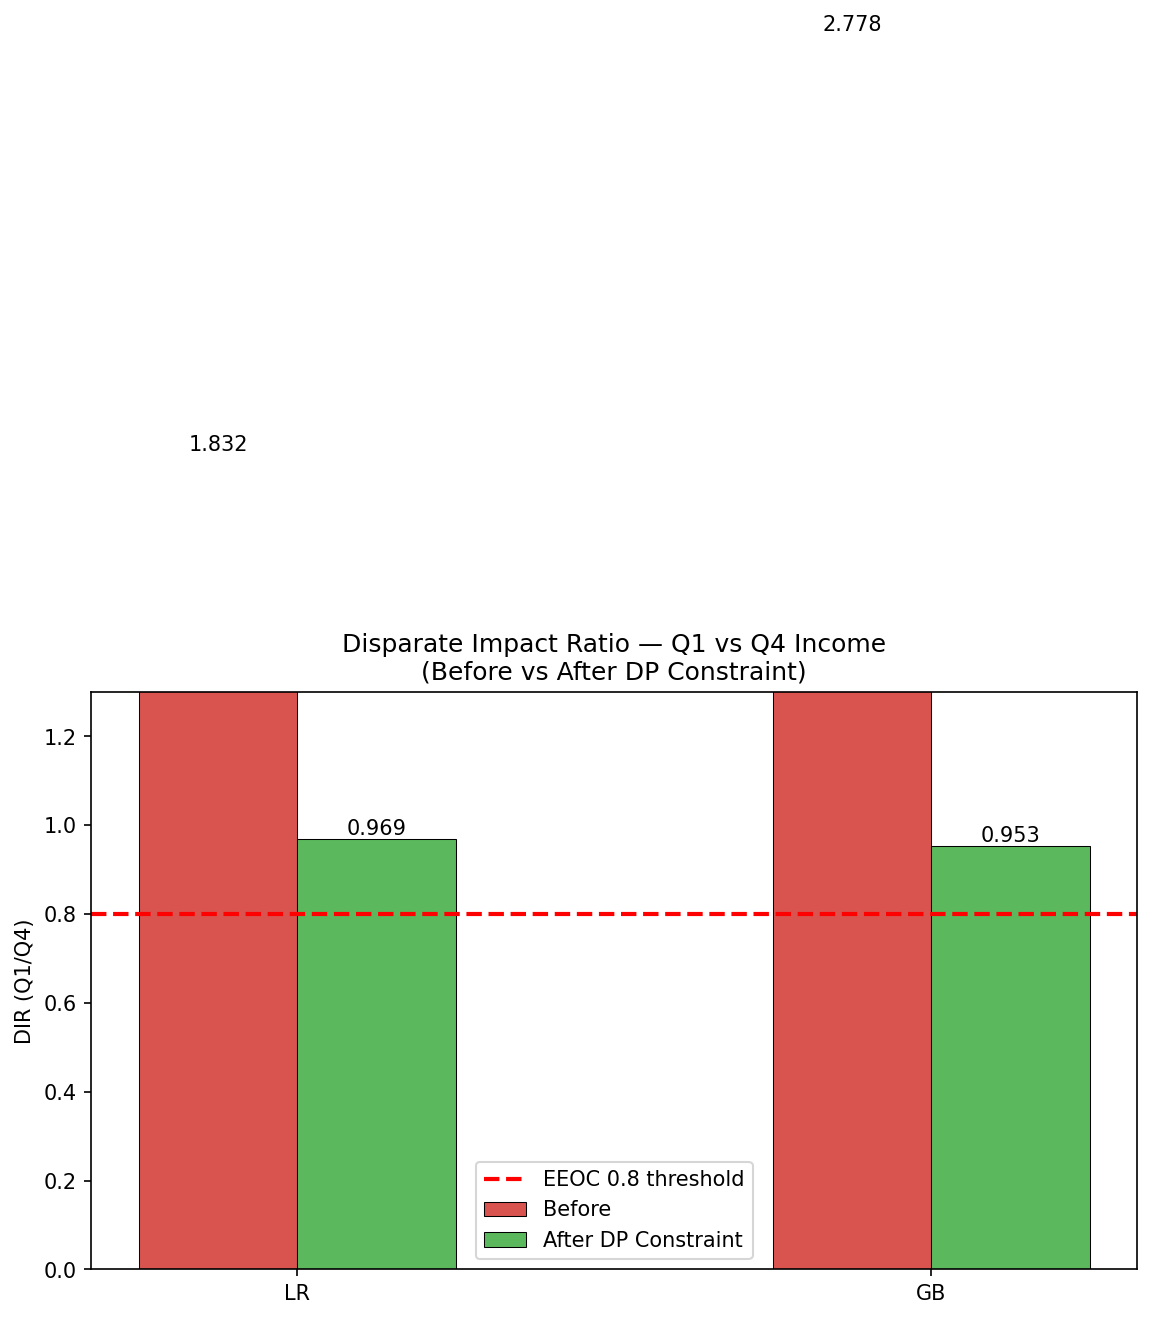

In [8]:
Image('../figures/stage2/lendingclub_dir_before_after.png')

## 7. F1 Comparison

F1 cost from DP constraint. GB maintains better F1 than LR under constraint.

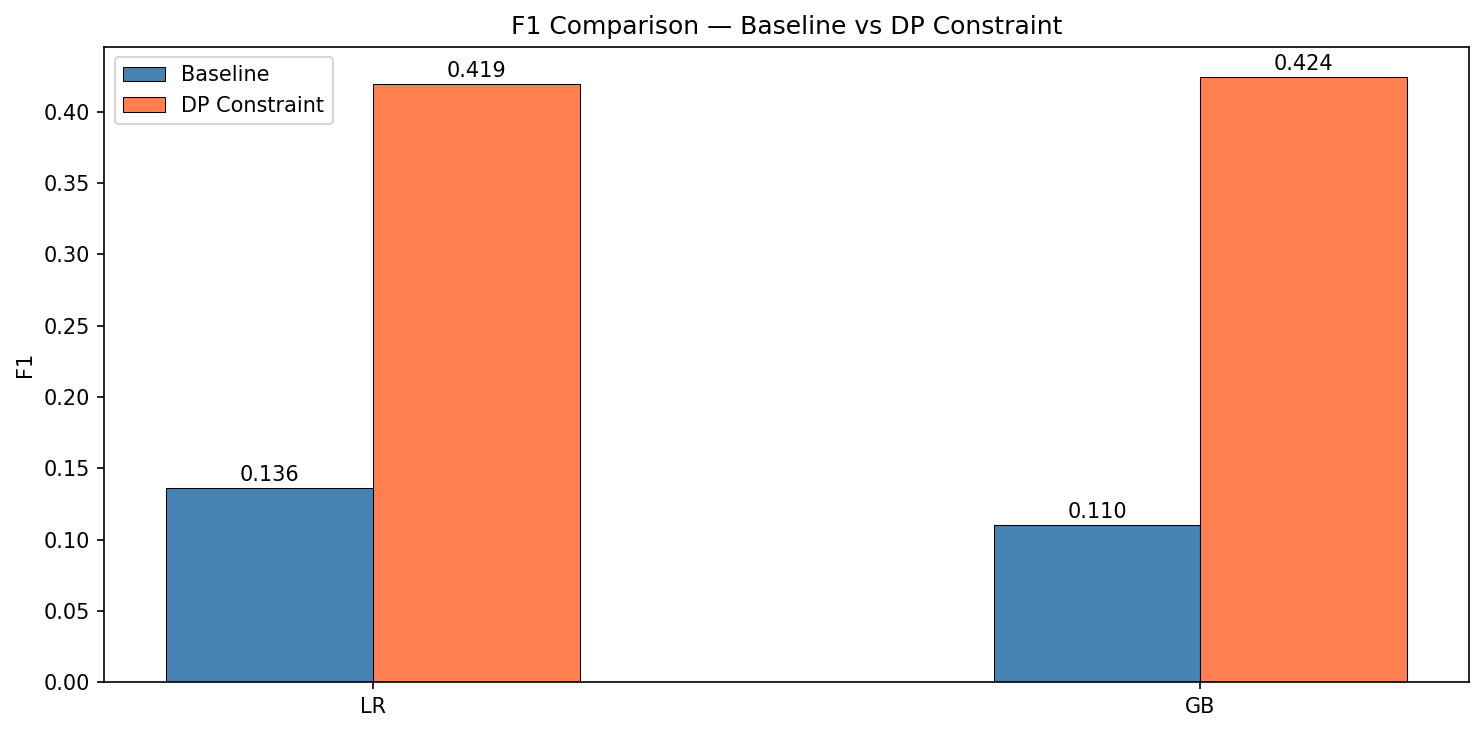

In [9]:
Image('../figures/stage2/lendingclub_f1_comparison.png')

## 8. FPR/FNR by Income Band

Baseline underpredicts default across all income bands (near-zero FPR). DP constraint raises FPR substantially, model now predicts default more aggressively across all groups.

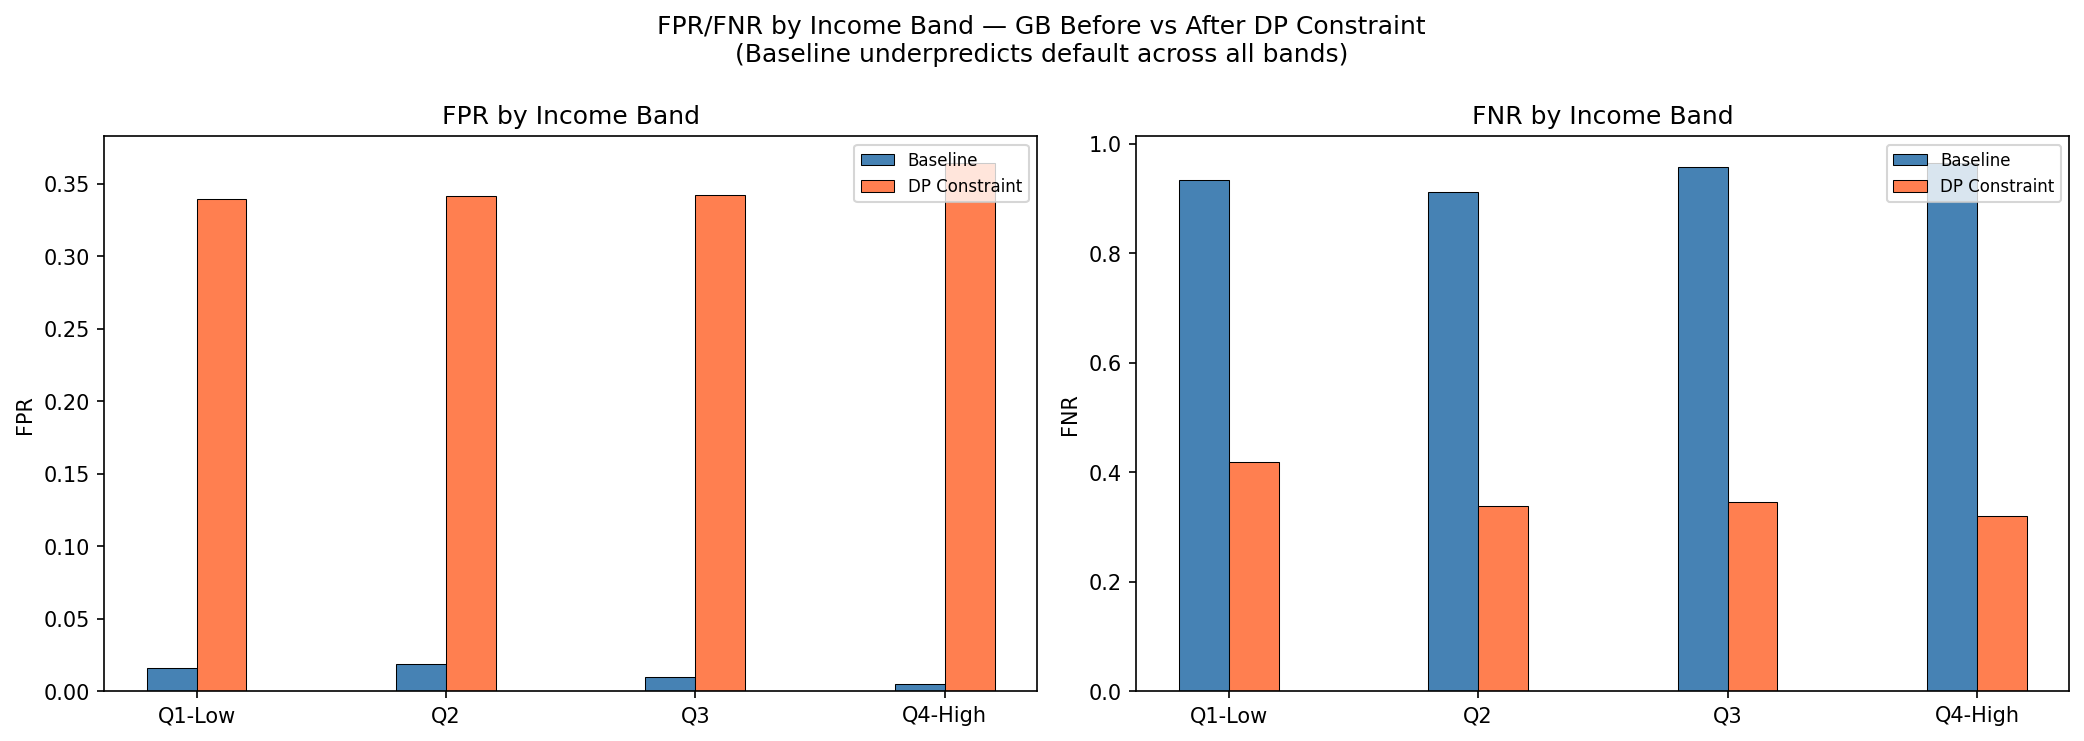

In [10]:
Image('../figures/stage2/lendingclub_fpr_fnr_by_income.png')

## 9. Key Findings

**Income DP gap minimal (0.018-0.024):** Smallest fairness gap in FAPE. Income band is a weak proxy, Lending Club's approval process already partially equalizes across income levels.

**DIR amplification:** Baseline model amplifies income disparity beyond actual rates. Actual default ratio Q1/Q4 = 1.4x. Predicted ratio = 2.8x. Model overpredicts default for low-income applicants.

**Home ownership gap dominates:** MORTGAGE vs RENT DP=0.138-0.178, 7-9x larger than income band gap. Renters are systematically predicted to default at higher rates.

**ThresholdOptimizer near-zero improvement:** When the baseline gap is small (0.018), ThresholdOptimizer has little room to improve. This is a valid cross-domain finding, not all fairness gaps require intervention.

**ECOA proxy audit:** No direct race/gender data. Income and housing as socioeconomic proxies consistent with Kozodoi et al. (2022) and Verma & Rubin (2018).